In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustrations 9.5-2 and 9.6-2 and Figure 9.6-2 &mdash; UNIFAC

This notebook reproduces **Illustrations 9.5-2 and 9.6-2** and **Figure 9.6-2** for
benzene / 2,2,4-trimethyl pentane, the third of three notebooks on one system.

Regular solution theory predicted these activity coefficients from two pure-component
numbers per species. UNIFAC predicts them from the *molecular structure* alone &mdash;
the molecules are taken apart into functional groups, and the groups carry the
parameters.

> ⭐ **Which UNIFAC?** *"UNIFAC"* names two models with different parameter sets. This
> chapter teaches **modified (Dortmund) UNIFAC**: Table 9.5-2 is the Dortmund parameter
> set, and the combinatorial term of Eq. 9.6-12a carries the
> $r_i^{3/4}$ weighting that is the Dortmund modification. `thermo.UNIFAC` is built with
> `kind="modified"` for that reason.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

In [3]:
# Weissman and Wood, benzene(B)/2,2,4-trimethyl pentane(TMP) at 55 C -- SIS
# Illustration 10.2-4. The same seven points the correlation notebook uses.
T = 328.15
xB    = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
yB    = np.array([0.1869, 0.4065, 0.5509, 0.5748, 0.6786, 0.8741, 0.9863])
P_bar = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])
Pvap_B, Pvap_TMP = 0.43596, 0.23738
gB = yB * P_bar / (xB * Pvap_B)
gT = (1 - yB) * P_bar / ((1 - xB) * Pvap_TMP)

## Taking the molecules apart (Illustration 9.5-2)

Benzene is six aromatic CH groups. 2,2,4-trimethyl pentane is five CH₃, one CH₂, one CH
and one C. The volume and surface area parameters follow by summation,

$$r_i = \sum_k \nu_k^{(i)} R_k \qquad q_i = \sum_k \nu_k^{(i)} Q_k$$

⚠️ **In the Dortmund set all four alkyl subgroups share $R = 0.6325$**, so the sum for
2,2,4-trimethyl pentane collapses to $8 \times 0.6325$. Only their surface areas differ.
That single fact is the most visible difference between this parameter set and the older
one, in which CH₃, CH₂, CH and C have four different volumes.

In [4]:
from thermo import UNIFAC
from thermo.data import load_unifac_subgroups, unifac_groups

subs = load_unifac_subgroups()
benzene = unifac_groups("benzene")          # from Table 9.5-2's own example column
tmp = {1: 5, 2: 1, 3: 1, 4: 1}              # 5 CH3, 1 CH2, 1 CH, 1 C
print("benzene  ", benzene)
print("2,2,4-TMP", tmp)
print()
print(subs[subs.subgroup_no.isin([1,2,3,4,9])][["subgroup_no","subgroup_name","main_group_name","R","Q"]]
      .to_string(index=False))

benzene   {9: 6}
2,2,4-TMP {1: 5, 2: 1, 3: 1, 4: 1}

 subgroup_no subgroup_name main_group_name      R      Q
           1           CH3             CH2 0.6325 1.0608
           2           CH2             CH2 0.6325 0.7081
           3            CH             CH2 0.6325 0.3554
           4             C             CH2 0.6325 0.0000
           9           ACH             ACH 0.3763 0.4321


In [5]:
Rk = dict(zip(subs.subgroup_no, subs.R)); Qk = dict(zip(subs.subgroup_no, subs.Q))
rq = lambda g: (sum(n*Rk[k] for k,n in g.items()), sum(n*Qk[k] for k,n in g.items()))
rB, qB_ = rq(benzene); rT, qT_ = rq(tmp)
print(f"benzene   r = {rB:.4f}  q = {qB_:.4f}      (Illustration 9.5-2: 2.2578, 2.5926)")
print(f"2,2,4-TMP r = {rT:.4f}  q = {qT_:.4f}      (Illustration 9.5-2: 5.0600, 6.3675)")

# the surface area and volume fractions the illustration asks for, at x = 0.5 each
from thermo import UNIQUACModel
uq = UNIQUACModel([rB, rT], [qB_, qT_], tau12=1.0, tau21=1.0)
print(f"\ntheta = {np.round(uq.theta([0.5,0.5]),3)}   (illustration: 0.289, 0.711)")
print(f"phi   = {np.round(uq.phi([0.5,0.5]),3)}   (illustration: 0.309, 0.691)")

benzene   r = 2.2578  q = 2.5926      (Illustration 9.5-2: 2.2578, 2.5926)
2,2,4-TMP r = 5.0600  q = 6.3675      (Illustration 9.5-2: 5.0600, 6.3675)

theta = [0.289 0.711]   (illustration: 0.289, 0.711)
phi   = [0.309 0.691]   (illustration: 0.309, 0.691)


## The prediction (Illustration 9.6-2)

Group $R$ and $Q$ give the combinatorial term. The residual term needs the group–group
interaction parameters $a_{nm}$, which the chapter does **not** print — they come from
`code/data/unifac_interactions_modified.csv`.

⚠️ **The book and the package do not compute the same $\Psi_{mn}$.** Equation 9.6-13b
prints $\Psi_{mn} = \exp(-a_{mn}/T)$, a single temperature-independent constant per
pair. Modified UNIFAC uses $a_{mn} + b_{mn}T + c_{mn}T^2$, and the parameter file carries
all three coefficients, so `thermo.UNIFAC` evaluates the full form. Where they differ,
the package is right — the printed equation is an incomplete statement of the model the
chapter names.

In [6]:
u = UNIFAC("modified")
print(f"{'xB':>8}{'UNIFAC gB':>11}{'exp gB':>9}   {'UNIFAC gTMP':>13}{'exp gTMP':>10}")
for i, a in enumerate(xB):
    g = u.gamma([benzene, tmp], [a, 1-a], T)
    print(f"{a:8.4f}{g[0]:11.3f}{gB[i]:9.3f}   {g[1]:13.3f}{gT[i]:10.3f}")

      xB  UNIFAC gB   exp gB     UNIFAC gTMP  exp gTMP
  0.0819      1.327    1.408           1.001     1.003
  0.2192      1.265    1.343           1.010     1.011
  0.3584      1.202    1.250           1.031     1.046
  0.3831      1.191    1.242           1.037     1.048
  0.5256      1.130    1.158           1.084     1.116
  0.8478      1.020    1.023           1.385     1.508
  0.9872      1.000    1.000           1.735     1.968


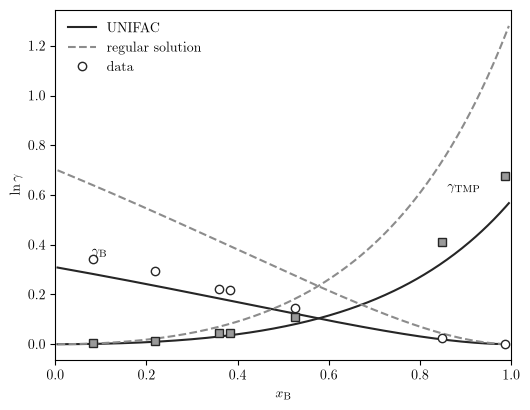

In [7]:
# The book plots ln gamma, not gamma (Figs. 9.5-4, 9.5-5, 9.6-1, 9.6-2 all do), and so
# do the other two notebooks in this three-model spine. Same ordinate here.
from thermo import RegularSolution
rs = RegularSolution.from_table_9_6_1([89, 165], [9.2, 6.93])
x = np.linspace(0.005, 0.995, 300)
gu = np.array([u.gamma([benzene, tmp], [a, 1-a], T) for a in x])
gr = np.array([rs.gamma([a, 1-a], T) for a in x])

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.plot(x, np.log(gu[:,0]), "-",  color="0.15", label="UNIFAC")
ax.plot(x, np.log(gu[:,1]), "-",  color="0.15")
ax.plot(x, np.log(gr[:,0]), "--", color="0.55", label="regular solution")
ax.plot(x, np.log(gr[:,1]), "--", color="0.55")
ax.plot(xB, np.log(gB), "o", mfc="white", color="0.15", label="data")
ax.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
ax.set_xlabel(r"$x_{\mathrm{B}}$"); ax.set_ylabel(r"$\ln\gamma$")
ax.set_xlim(0, 1); ax.legend(frameon=False)
ax.annotate(r"$\gamma_{\mathrm{TMP}}$", (0.86, 0.62)); ax.annotate(r"$\gamma_{\mathrm{B}}$", (0.08, 0.36))
fig.tight_layout()

wrote pdf/Fig_9.6-2.pdf


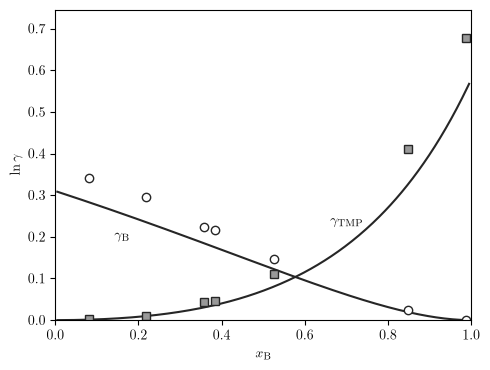

In [8]:
# --- Print art: Figure 9.6-2 -----------------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f008.pdf
#
# Redrawn to the printed figure's own conventions, checked against the 5e art
# (c09f008.jpg): ordinate is ln(gamma); UNIFAC AND THE DATA ONLY -- "UNIFAC
# predictions ... The points are activity coefficients derived from experimental
# data", so the regular-solution comparison above is dropped; the two curves are
# as gamma_B and gamma_TMP; and there is NO legend.
#
# TWO marker styles for the data -- open circles for benzene, filled squares for
# 2,2,4-trimethyl pentane. This is a DELIBERATE departure from the 5e art, which
# uses one marker for both species: with two curves crossing, keying the points to
# their species makes the figure markedly easier to read and costs nothing in black
# and white. The caption should say which marker is which.
import os
os.makedirs("pdf", exist_ok=True)

luB, luT = np.log(gu[:, 0]), np.log(gu[:, 1])

f, a = plt.subplots(figsize=(5.0, 3.8))
a.plot(x, luB, "-", color="0.15")
a.plot(x, luT, "-", color="0.15")
a.plot(xB, np.log(gB), "o", mfc="white", color="0.15")
a.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
a.set_xlabel(r"$x_{\mathrm{B}}$"); a.set_ylabel(r"$\ln\gamma$")
a.set_xlim(0, 1)
BOT = 0.0
top = 1.10 * max(luB.max(), luT.max(), np.log(gB).max(), np.log(gT).max())
a.set_ylim(BOT, top)

# Each label sits just off its OWN curve, on the side where the other curve is
# furthest away. The offset is a fraction of the axis height, so it survives a
# change of y limit.
span = top - BOT
a.text(0.16, np.interp(0.16, x, luB) - 0.05 * span,
       r"$\gamma_{\mathrm{B}}$", ha="center", va="top")
a.text(0.70, np.interp(0.70, x, luT) + 0.06 * span,
       r"$\gamma_{\mathrm{TMP}}$", ha="center", va="bottom")

f.tight_layout()
f.savefig("pdf/Fig_9.6-2.pdf", dpi=300, bbox_inches="tight")
#plt.close(f)
print("wrote pdf/Fig_9.6-2.pdf")

In [9]:
def rms(pred):
    return np.sqrt(np.mean((np.log(pred[:,0])-np.log(gB))**2 + (np.log(pred[:,1])-np.log(gT))**2))
gu_pts = np.array([u.gamma([benzene, tmp], [a, 1-a], T) for a in xB])
gr_pts = np.array([rs.gamma([a, 1-a], T) for a in xB])
print("RMS residual in ln gamma over the seven points, both species:")
print(f"  UNIFAC            {rms(gu_pts):.4f}")
print(f"  regular solution  {rms(gr_pts):.4f}")

RMS residual in ln gamma over the seven points, both species:
  UNIFAC            0.0710
  regular solution  0.3076


## What the comparison shows

UNIFAC is markedly better than regular solution theory and still not as good as the
two-constant correlations of the first notebook — which is exactly the ordering one
should expect, and the point of running all three on one system:

| | what it needs | what it gets |
|---|---|---|
| van Laar | two constants **fitted to this mixture** | the data, closely |
| UNIFAC | the structural formulas, and a group parameter table | most of the shape, a systematic under-prediction |
| regular solution | two pure-component numbers per species | the right sign, about twice the magnitude |

⛔ **Do not tune anything to close the UNIFAC gap.** The under-prediction is the result.
It is what a group-contribution method costs: benzene's ACH groups and the alkyl groups
of 2,2,4-trimethyl pentane are described by parameters regressed over hundreds of other
mixtures, and this particular pair is not among the systems the fit was weighted
towards.

**Your turn.** Predict the activity coefficients for benzene / cyclohexane at 25 °C
(cyclohexane is six `cy-CH2` groups — `unifac_groups("cyclohexane")` will find them) and
compare with the regular solution prediction from the previous notebook's exercise. Does
the ranking of the two models survive a change of system?